Interpretability papers often implicitly assume something like:

First the network detects parts, then whole objects, then subclasses/fine-grained identities.

For example, Concept Bottleneck Models (CBMs) assume you can factor the prediction through human concepts (attributes, parts) and that these are the “natural internal representation” of the model. (https://arxiv.org/abs/2007.04612)

Does a real network on CUB actually organize information in that human-intuitive order? Or do parts, objects, and species all become linearly decodable at roughly the same time, or in some unexpected order?

In this notebook, I set up the structure I want to test:
- **Subclass**: bird species (200-way classification)
- **Part concepts**: binary presence of key parts (e.g., beak, wing)
- (Maybe later) **Superclasses**: coarser groupings of species

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from datasets.cub_metadata import load_cub_metadata

cub_root = Path("../data/CUB_200_2011/")
meta = load_cub_metadata(cub_root)

images_df = meta.images
classes_df = meta.classes
parts_df = meta.parts
part_locs_df = meta.part_locs
ipb_df = meta.image_parts_binary # Check if preprocessing code has run before doing this 


## 1. Inspect species and images


In [4]:
print("Number of images:", len(images_df))
print("Number of classes:", len(classes_df))
classes_df.head()

Number of images: 11788
Number of classes: 200


,class_id,class_name
0,1,001.Black_footed_Albatross
1,2,002.Laysan_Albatross
2,3,003.Sooty_Albatross
3,4,004.Groove_billed_Ani
4,5,005.Crested_Auklet


Each class corresponds to a bird species (e.g., `001.Black_footed_Albatross`),
and each image is assigned one of these classes via `image_class_labels.txt`.

I will treat these 200 classes as the *subclass labels* that all my models and probes try to predict.

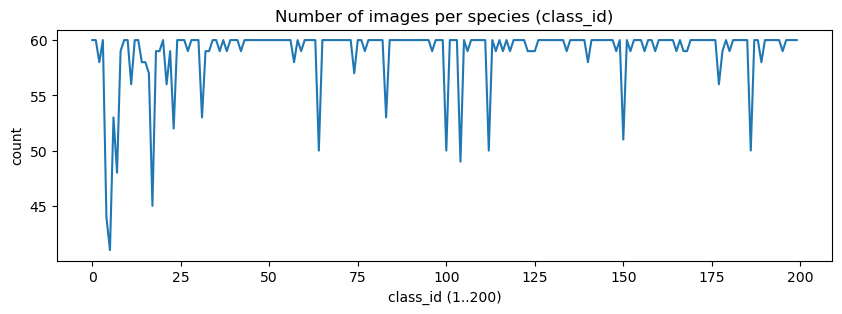

In [5]:
class_counts = images_df["class_id"].value_counts().sort_index()
plt.figure(figsize=(10, 3))
plt.plot(class_counts.values)
plt.title("Number of images per species (class_id)")
plt.xlabel("class_id (1..200)")
plt.ylabel("count")
plt.show()


## 2. Inspect part annotations

CUB also provides part annotations (e.g., beak, left eye, right wing) for many images.

These are given as `(image_id, part_id, x, y, visible)` tuples, plus a list of part names.
I will treat these as the basis for *part concepts*, but I will only use them at image level:

`Is this part visible somewhere in the image? → make into binary label per part.`


In [6]:
print("Number of parts defined:", len(parts_df))
parts_df.head()

Number of parts defined: 15


,part_id,part_name
0,1,back
1,2,beak
2,3,belly
3,4,breast
4,5,crown


In [7]:
part_locs_df.head()

,image_id,part_id,x,y,visible
0,1,1,0.0,0.0,0
1,1,2,312.0,182.0,1
2,1,3,0.0,0.0,0
3,1,4,0.0,0.0,0
4,1,5,186.0,45.0,1


To make part concepts usable for probes, I collapse the raw part locations into
binary indicators of whether a part is visible in a given image. i created `image_parts_binary.csv` for this.z

In [8]:
if ipb_df is not None:
    print("image_parts_binary shape:", ipb_df.shape)
    ipb_df.head()
else:
    print("image_parts_binary.csv not found. Run scripts/prepare_cub_metadata.py?")


image_parts_binary shape: (11788, 16)


For the initial experiments, I won't use all parts. Instead, I will select a small,
interpretable subset (for example, the first few parts in `parts.txt`) so that
I can plot and discuss them in detail:

In [9]:
# all columns except 'image_id'
part_cols = [c for c in ipb_df.columns if c.startswith("part_")]
print("Total part concepts available:", len(part_cols))
chosen_part_cols = part_cols[:5]
print("Chosen part columns for initial experiments:", chosen_part_cols)

Total part concepts available: 15
Chosen part columns for initial experiments: ['part_1_present', 'part_2_present', 'part_3_present', 'part_4_present', 'part_5_present']


I will use these targets to train probes on frozen features
from different layers of a ResNet, in order to test at what depth in the network does each type of information become linearly decodable.